# 10 Supplementary Media Tone Indicator

This notebook adds a transparent, dictionary-based media tone proxy as a supplementary diagnostic layer.

Positioning:
- Main analysis remains salience + framing/content indicators.
- Tone is a descriptive complement for mechanism interpretation.
- No causal claims.


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 260)
pd.set_option('display.width', 220)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
CORPUS_DIR = DATA_DIR / 'corpus'
INDICATORS_DIR = DATA_DIR / 'indicators'
PANEL_DIR = DATA_DIR / 'panel'
FIGURES_DIR = PROJECT_ROOT / 'figures' / '10_notebook_figures'
DOCS_DIR = PROJECT_ROOT / 'docs'

INDICATORS_DIR.mkdir(parents=True, exist_ok=True)
PANEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)

MASTER_PARQUET = CORPUS_DIR / 'master_articles.parquet'
MASTER_CSV = CORPUS_DIR / 'master_articles_light.csv'
FULL_PANEL_PARQUET = PANEL_DIR / 'monthly_full_analysis_panel_2013_2025.parquet'
FULL_PANEL_CSV = PANEL_DIR / 'monthly_full_analysis_panel_2013_2025.csv'

ARTICLE_TONE_CSV = INDICATORS_DIR / 'article_media_tone_indicators.csv'
ARTICLE_TONE_PARQUET = INDICATORS_DIR / 'article_media_tone_indicators.parquet'
MONTHLY_TONE_CSV = INDICATORS_DIR / 'monthly_media_tone_indicators.csv'
MONTHLY_TONE_PARQUET = INDICATORS_DIR / 'monthly_media_tone_indicators.parquet'

FULL_PANEL_TONE_CSV = PANEL_DIR / 'monthly_full_analysis_panel_with_tone_2013_2025.csv'
FULL_PANEL_TONE_PARQUET = PANEL_DIR / 'monthly_full_analysis_panel_with_tone_2013_2025.parquet'
TONE_SHOCK_SUMMARY_CSV = PANEL_DIR / 'supplementary_tone_shock_window_summary.csv'

SUPP_NOTE_MD = DOCS_DIR / 'supplementary_media_tone_results_note.md'

EXPECTED_TONE_RANGE = pd.period_range('2013-01', '2025-12', freq='M')
EXPECTED_PANEL_RANGE = pd.period_range('2013-09', '2025-12', freq='M')
EXPECTED_PANEL_ROWS = len(EXPECTED_PANEL_RANGE)

SHOCKS = {
    'Cologne': pd.Timestamp('2016-01-01'),
    'Chemnitz': pd.Timestamp('2018-08-01'),
    'Correctiv': pd.Timestamp('2024-01-01'),
}

KEY_EXISTING_COLS = [
    'afd_poll_support_mean',
    'nexis_total_results',
    'migration_terms_per_1000_mean',
    'security_terms_per_1000_mean',
    'afd_far_right_terms_per_1000_mean',
    'remigration_democracy_terms_per_1000_mean',
]

print('MASTER_PARQUET:', MASTER_PARQUET)
print('FULL_PANEL_PARQUET:', FULL_PANEL_PARQUET)
print('ARTICLE_TONE_CSV:', ARTICLE_TONE_CSV)
print('MONTHLY_TONE_CSV:', MONTHLY_TONE_CSV)
print('FULL_PANEL_TONE_CSV:', FULL_PANEL_TONE_CSV)
print('FIGURES_DIR:', FIGURES_DIR)


MASTER_PARQUET: c:\PythonProjects\AfD-project\data\corpus\master_articles.parquet
FULL_PANEL_PARQUET: c:\PythonProjects\AfD-project\data\panel\monthly_full_analysis_panel_2013_2025.parquet
ARTICLE_TONE_CSV: c:\PythonProjects\AfD-project\data\indicators\article_media_tone_indicators.csv
MONTHLY_TONE_CSV: c:\PythonProjects\AfD-project\data\indicators\monthly_media_tone_indicators.csv
FULL_PANEL_TONE_CSV: c:\PythonProjects\AfD-project\data\panel\monthly_full_analysis_panel_with_tone_2013_2025.csv
FIGURES_DIR: c:\PythonProjects\AfD-project\figures\10_notebook_figures


In [2]:
def load_table(parquet_path: Path, csv_path: Path, label: str) -> pd.DataFrame:
    if parquet_path.exists():
        print(f'Loaded {label} from parquet: {parquet_path}')
        return pd.read_parquet(parquet_path)
    if csv_path.exists():
        print(f'Loaded {label} from csv: {csv_path}')
        return pd.read_csv(csv_path)
    raise FileNotFoundError(f'Missing {label}: {parquet_path} and {csv_path}')

master = load_table(MASTER_PARQUET, MASTER_CSV, 'master corpus').copy()
full_panel = load_table(FULL_PANEL_PARQUET, FULL_PANEL_CSV, 'full analysis panel').copy()

required_master = ['keep_drop_review', 'date', 'article_id', 'text_body']
missing_master = [c for c in required_master if c not in master.columns]
if missing_master:
    raise ValueError(f'Master corpus missing required columns: {missing_master}')

kept = master[master['keep_drop_review'].astype(str).str.lower() == 'keep'].copy()
if kept.empty:
    raise ValueError('Kept corpus is empty.')

kept['date'] = pd.to_datetime(kept['date'], errors='coerce')
if kept['date'].isna().any():
    raise ValueError('Date parsing failed for some kept articles.')

kept['month_dt'] = kept['date'].dt.to_period('M').dt.to_timestamp()
kept['year_month'] = kept['month_dt'].dt.strftime('%Y-%m')
kept['year'] = kept['month_dt'].dt.year
kept['month_num'] = kept['month_dt'].dt.month

full_panel['year_month'] = full_panel['year_month'].astype(str)
full_panel['month_dt'] = pd.to_datetime(full_panel['year_month'] + '-01', errors='coerce')
if full_panel['month_dt'].isna().any():
    raise ValueError('Full panel year_month parsing failed.')
if len(full_panel) != EXPECTED_PANEL_ROWS:
    raise ValueError(f'Full panel row mismatch: {len(full_panel)} vs expected {EXPECTED_PANEL_ROWS}')
if full_panel['year_month'].duplicated().any():
    raise ValueError('Full panel has duplicate months.')

panel_periods = pd.PeriodIndex(full_panel['year_month'], freq='M')
missing_panel = EXPECTED_PANEL_RANGE.difference(panel_periods)
extra_panel = panel_periods.difference(EXPECTED_PANEL_RANGE)
if len(missing_panel) > 0 or len(extra_panel) > 0:
    raise ValueError(
        'Full panel coverage mismatch. '
        f'missing={ [p.strftime("%Y-%m") for p in missing_panel] }, '
        f'extra={ [p.strftime("%Y-%m") for p in extra_panel] }'
    )

missing_existing_key = [c for c in KEY_EXISTING_COLS if c not in full_panel.columns]
if missing_existing_key:
    raise ValueError(f'Full panel missing existing key columns: {missing_existing_key}')

print('Validation summary:')
print('kept rows:', len(kept))
print('kept coverage:', kept['year_month'].min(), 'to', kept['year_month'].max())
print('full panel rows:', len(full_panel), 'coverage:', full_panel['year_month'].min(), 'to', full_panel['year_month'].max())


Loaded master corpus from parquet: c:\PythonProjects\AfD-project\data\corpus\master_articles.parquet
Loaded full analysis panel from parquet: c:\PythonProjects\AfD-project\data\panel\monthly_full_analysis_panel_2013_2025.parquet
Validation summary:
kept rows: 9367
kept coverage: 2013-01 to 2025-12
full panel rows: 148 coverage: 2013-09 to 2025-12


In [3]:
# Reuse Notebook 07 German normalization logic.
GERMAN_CHAR_MAP = str.maketrans({
    "ä": "ae", "ö": "oe", "ü": "ue", "ß": "ss",
    "Ä": "ae", "Ö": "oe", "Ü": "ue",
})

def normalize_german_ascii(text: str) -> str:
    if text is None:
        return ''
    s = str(text).translate(GERMAN_CHAR_MAP).lower()
    s = re.sub(r'[^a-z0-9\s]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

_umlaut_probe = normalize_german_ascii('Flüchtlinge äußern größere Sorge über Abschiebung')
assert 'fluechtlinge' in _umlaut_probe
assert 'aeussern' in _umlaut_probe
assert 'groessere' in _umlaut_probe
assert 'ueber' in _umlaut_probe
assert 'auslaender' in normalize_german_ascii('Ausländer')
assert 'uebergriff' in normalize_german_ascii('Übergriff')
print('German normalization assertions passed.')

# Transparent supplementary evaluative tone lexicon (German-normalized stems).
POSITIVE_PATTERNS = [
    r'\berfolg\w*\b',
    r'\bgeling\w*\b',
    r'\bverbesser\w*\b',
    r'\bhoffnung\w*\b',
    r'\bchanc\w*\b',
    r'\bstabil\w*\b',
    r'\bentspann\w*\b',
    r'\bunterstuetz\w*\b',
    r'\bhilf\w*\b',
    r'\bintegrationserfolg\w*\b',
    r'\bsolidar\w*\b',
    r'\baufschwung\w*\b',
    r'\bfortschritt\w*\b',
    r'\bloesung\w*\b',
    r'\bentlast\w*\b',
]

NEGATIVE_PATTERNS = [
    r'\bangst\w*\b',
    r'\bsorg\w*\b',
    r'\bkris\w*\b',
    r'\bchaos\w*\b',
    r'\bproblem\w*\b',
    r'\bkonflikt\w*\b',
    r'\bgewalt\w*\b',
    r'\bbedroh\w*\b',
    r'\bgefahr\w*\b',
    r'\bskandal\w*\b',
    r'\billegal\w*\b',
    r'\bextrem\w*\b',
    r'\bradikal\w*\b',
    r'\bueberforderung\w*\b',
    r'\bscheiter\w*\b',
    r'\bversag\w*\b',
    r'\bkritik\w*\b',
    r'\bbelast\w*\b',
    r'\bmissbrauch\w*\b',
    r'\bkriminal\w*\b',
]

POSITIVE_RE = re.compile('|'.join(POSITIVE_PATTERNS))
NEGATIVE_RE = re.compile('|'.join(NEGATIVE_PATTERNS))

print('Positive lexicon size:', len(POSITIVE_PATTERNS))
print('Negative lexicon size:', len(NEGATIVE_PATTERNS))



German normalization assertions passed.
Positive lexicon size: 15
Negative lexicon size: 20


In [4]:
def count_tone_terms(norm_text: str) -> tuple[int, int]:
    pos = len(POSITIVE_RE.findall(norm_text))
    neg = len(NEGATIVE_RE.findall(norm_text))
    return pos, neg

kept['text_normalized'] = kept['text_body'].fillna('').map(normalize_german_ascii)
kept['text_token_count'] = kept['text_normalized'].str.split().map(len)

wc = pd.to_numeric(kept.get('word_count', np.nan), errors='coerce')
kept['word_count_used'] = wc.where(wc > 0, kept['text_token_count'])
kept['word_count_used'] = kept['word_count_used'].fillna(kept['text_token_count'])

pairs = kept['text_normalized'].map(count_tone_terms)
kept['tone_positive_terms_count'] = pairs.map(lambda x: x[0])
kept['tone_negative_terms_count'] = pairs.map(lambda x: x[1])

kept['tone_positive_terms_per_1000'] = np.where(
    kept['word_count_used'] > 0,
    kept['tone_positive_terms_count'] * 1000.0 / kept['word_count_used'],
    0.0,
)
kept['tone_negative_terms_per_1000'] = np.where(
    kept['word_count_used'] > 0,
    kept['tone_negative_terms_count'] * 1000.0 / kept['word_count_used'],
    0.0,
)
kept['tone_net_score_per_1000'] = kept['tone_positive_terms_per_1000'] - kept['tone_negative_terms_per_1000']

denom = kept['tone_positive_terms_count'] + kept['tone_negative_terms_count']
# Explicit rule for undefined denominator: set share to 0.5 (neutral balance proxy).
kept['tone_negative_share'] = np.where(denom > 0, kept['tone_negative_terms_count'] / denom, 0.5)

# Transparent thresholds for simple tone labels.
kept['tone_label_simple'] = np.select(
    [
        kept['tone_net_score_per_1000'] > 0.5,
        kept['tone_net_score_per_1000'] < -0.5,
    ],
    ['positive', 'negative'],
    default='neutral'
)

article_cols = [
    'article_id', 'date', 'year_month', 'month_dt', 'year', 'month_num',
    'word_count_used',
    'tone_positive_terms_count', 'tone_negative_terms_count',
    'tone_positive_terms_per_1000', 'tone_negative_terms_per_1000',
    'tone_net_score_per_1000', 'tone_negative_share', 'tone_label_simple',
]
article_tone = kept[article_cols].copy().sort_values(['month_dt', 'article_id']).reset_index(drop=True)

article_tone.to_csv(ARTICLE_TONE_CSV, index=False)
article_tone.to_parquet(ARTICLE_TONE_PARQUET, index=False)

pos_total = int(article_tone['tone_positive_terms_count'].sum())
neg_total = int(article_tone['tone_negative_terms_count'].sum())

if pos_total == 0 or neg_total == 0:
    raise ValueError(f'Tone totals invalid (must be non-zero). positive={pos_total}, negative={neg_total}')

print('Saved article tone CSV:', ARTICLE_TONE_CSV)
print('Saved article tone parquet:', ARTICLE_TONE_PARQUET)
print('article_tone shape:', article_tone.shape)
print('Tone term totals -> positive:', pos_total, 'negative:', neg_total)
print('Tone label shares:')
print(article_tone['tone_label_simple'].value_counts(normalize=True).rename('share').to_string())


Saved article tone CSV: c:\PythonProjects\AfD-project\data\indicators\article_media_tone_indicators.csv
Saved article tone parquet: c:\PythonProjects\AfD-project\data\indicators\article_media_tone_indicators.parquet
article_tone shape: (9367, 14)
Tone term totals -> positive: 20837 negative: 25804
Tone label shares:
tone_label_simple
negative    0.433543
positive    0.360841
neutral     0.205615


In [5]:
monthly = (
    article_tone.groupby('year_month', as_index=False)
    .agg(
        n_articles_tone_indicators=('article_id', 'size'),
        tone_positive_terms_total=('tone_positive_terms_count', 'sum'),
        tone_negative_terms_total=('tone_negative_terms_count', 'sum'),
        tone_positive_terms_per_1000_mean=('tone_positive_terms_per_1000', 'mean'),
        tone_negative_terms_per_1000_mean=('tone_negative_terms_per_1000', 'mean'),
        tone_net_score_per_1000_mean=('tone_net_score_per_1000', 'mean'),
        tone_negative_share_mean=('tone_negative_share', 'mean'),
        share_articles_negative_tone=('tone_label_simple', lambda s: (s == 'negative').mean()),
        share_articles_positive_tone=('tone_label_simple', lambda s: (s == 'positive').mean()),
        share_articles_neutral_tone=('tone_label_simple', lambda s: (s == 'neutral').mean()),
    )
)

full_months = pd.DataFrame({'year_month': EXPECTED_TONE_RANGE.strftime('%Y-%m')})
full_months['month_dt'] = EXPECTED_TONE_RANGE.to_timestamp()
full_months['year'] = full_months['month_dt'].dt.year
full_months['month_num'] = full_months['month_dt'].dt.month
full_months['month'] = full_months['year_month']

monthly_tone = full_months.merge(monthly, on='year_month', how='left')

for col in ['n_articles_tone_indicators', 'tone_positive_terms_total', 'tone_negative_terms_total']:
    monthly_tone[col] = monthly_tone[col].fillna(0).astype(int)

mean_cols_fill_zero = [
    'tone_positive_terms_per_1000_mean',
    'tone_negative_terms_per_1000_mean',
    'tone_net_score_per_1000_mean',
]
for col in mean_cols_fill_zero:
    monthly_tone[col] = monthly_tone[col].fillna(0.0)

# Explicit undefined-denominator handling propagated monthly: neutral balance at 0.5.
monthly_tone['tone_negative_share_mean'] = monthly_tone['tone_negative_share_mean'].fillna(0.5)

for col in ['share_articles_negative_tone', 'share_articles_positive_tone']:
    monthly_tone[col] = monthly_tone[col].fillna(0.0)
monthly_tone['share_articles_neutral_tone'] = monthly_tone['share_articles_neutral_tone'].fillna(1.0)

monthly_tone['tone_month_has_articles'] = monthly_tone['n_articles_tone_indicators'] > 0

monthly_tone = monthly_tone[
    [
        'month', 'year_month', 'month_dt', 'year', 'month_num', 'tone_month_has_articles',
        'n_articles_tone_indicators',
        'tone_positive_terms_total', 'tone_negative_terms_total',
        'tone_positive_terms_per_1000_mean', 'tone_negative_terms_per_1000_mean',
        'tone_net_score_per_1000_mean', 'tone_negative_share_mean',
        'share_articles_negative_tone', 'share_articles_positive_tone', 'share_articles_neutral_tone',
    ]
].sort_values('month_dt').reset_index(drop=True)

if monthly_tone['year_month'].duplicated().any():
    raise ValueError('Monthly tone has duplicate months.')
if len(monthly_tone) != len(EXPECTED_TONE_RANGE):
    raise ValueError(f'Monthly tone row mismatch: {len(monthly_tone)} vs {len(EXPECTED_TONE_RANGE)}')

monthly_tone.to_csv(MONTHLY_TONE_CSV, index=False)
monthly_tone.to_parquet(MONTHLY_TONE_PARQUET, index=False)

print('Saved monthly tone CSV:', MONTHLY_TONE_CSV)
print('Saved monthly tone parquet:', MONTHLY_TONE_PARQUET)
print('monthly_tone shape:', monthly_tone.shape)
print('monthly tone coverage:', monthly_tone['year_month'].min(), 'to', monthly_tone['year_month'].max())


Saved monthly tone CSV: c:\PythonProjects\AfD-project\data\indicators\monthly_media_tone_indicators.csv
Saved monthly tone parquet: c:\PythonProjects\AfD-project\data\indicators\monthly_media_tone_indicators.parquet
monthly_tone shape: (156, 16)
monthly tone coverage: 2013-01 to 2025-12


In [6]:
tone_merge_cols = [
    'year_month',
    'n_articles_tone_indicators',
    'tone_positive_terms_total',
    'tone_negative_terms_total',
    'tone_positive_terms_per_1000_mean',
    'tone_negative_terms_per_1000_mean',
    'tone_net_score_per_1000_mean',
    'tone_negative_share_mean',
    'share_articles_negative_tone',
    'share_articles_positive_tone',
    'share_articles_neutral_tone',
]

panel_tone = full_panel.merge(monthly_tone[tone_merge_cols], on='year_month', how='left', validate='one_to_one')
panel_tone['month_dt'] = pd.to_datetime(panel_tone['year_month'] + '-01', errors='coerce')
panel_tone = panel_tone.sort_values('month_dt').reset_index(drop=True)

if len(panel_tone) != EXPECTED_PANEL_ROWS:
    raise ValueError(f'Panel with tone row mismatch: {len(panel_tone)} vs {EXPECTED_PANEL_ROWS}')
if panel_tone['year_month'].duplicated().any():
    raise ValueError('Panel with tone has duplicate months.')

missing_existing = {c: int(panel_tone[c].isna().sum()) for c in KEY_EXISTING_COLS}
if any(v > 0 for v in missing_existing.values()):
    raise ValueError(f'Missing existing key values after merge: {missing_existing}')

tone_key_cols = [
    'n_articles_tone_indicators',
    'tone_positive_terms_total',
    'tone_negative_terms_total',
    'tone_positive_terms_per_1000_mean',
    'tone_negative_terms_per_1000_mean',
    'tone_net_score_per_1000_mean',
    'tone_negative_share_mean',
    'share_articles_negative_tone',
]
missing_tone = {c: int(panel_tone[c].isna().sum()) for c in tone_key_cols}
if any(v > 0 for v in missing_tone.values()):
    raise ValueError(f'Missing tone values in panel months: {missing_tone}')

panel_tone.to_csv(FULL_PANEL_TONE_CSV, index=False)
panel_tone.to_parquet(FULL_PANEL_TONE_PARQUET, index=False)

print('Saved panel with tone CSV:', FULL_PANEL_TONE_CSV)
print('Saved panel with tone parquet:', FULL_PANEL_TONE_PARQUET)
print('panel_tone shape:', panel_tone.shape)
print('panel_tone coverage:', panel_tone['year_month'].min(), 'to', panel_tone['year_month'].max())
print('Missing existing key values:', missing_existing)
print('Missing tone key values:', missing_tone)


Saved panel with tone CSV: c:\PythonProjects\AfD-project\data\panel\monthly_full_analysis_panel_with_tone_2013_2025.csv
Saved panel with tone parquet: c:\PythonProjects\AfD-project\data\panel\monthly_full_analysis_panel_with_tone_2013_2025.parquet
panel_tone shape: (148, 77)
panel_tone coverage: 2013-09 to 2025-12
Missing existing key values: {'afd_poll_support_mean': 0, 'nexis_total_results': 0, 'migration_terms_per_1000_mean': 0, 'security_terms_per_1000_mean': 0, 'afd_far_right_terms_per_1000_mean': 0, 'remigration_democracy_terms_per_1000_mean': 0}
Missing tone key values: {'n_articles_tone_indicators': 0, 'tone_positive_terms_total': 0, 'tone_negative_terms_total': 0, 'tone_positive_terms_per_1000_mean': 0, 'tone_negative_terms_per_1000_mean': 0, 'tone_net_score_per_1000_mean': 0, 'tone_negative_share_mean': 0, 'share_articles_negative_tone': 0}


In [7]:
summary_vars = [
    'afd_poll_support_mean',
    'nexis_total_results',
    'migration_terms_per_1000_mean',
    'security_terms_per_1000_mean',
    'afd_far_right_terms_per_1000_mean',
    'remigration_democracy_terms_per_1000_mean',
    'tone_negative_terms_per_1000_mean',
    'tone_net_score_per_1000_mean',
    'tone_negative_share_mean',
    'share_articles_negative_tone',
]

rows = []
for shock_label, shock_month in SHOCKS.items():
    for win in [3, 6]:
        w = panel_tone[
            (panel_tone['month_dt'] >= shock_month - pd.DateOffset(months=win))
            & (panel_tone['month_dt'] <= shock_month + pd.DateOffset(months=win))
        ].copy()
        w['rel_month'] = ((w['month_dt'].dt.year - shock_month.year) * 12 + (w['month_dt'].dt.month - shock_month.month)).astype(int)

        pre = w[w['rel_month'] < 0]
        post = w[w['rel_month'] > 0]
        shock_row = w[w['rel_month'] == 0]

        for var in summary_vars:
            rows.append({
                'shock_label': shock_label,
                'shock_month': shock_month.strftime('%Y-%m'),
                'window_months': win,
                'variable': var,
                'pre_mean': pre[var].mean(),
                'post_mean': post[var].mean(),
                'change_post_minus_pre': post[var].mean() - pre[var].mean(),
                'shock_month_value': shock_row[var].iloc[0] if len(shock_row) == 1 else np.nan,
                'n_months_pre': len(pre),
                'n_months_post': len(post),
            })

supp_shock = pd.DataFrame(rows)
supp_shock.to_csv(TONE_SHOCK_SUMMARY_CSV, index=False)

print('Saved supplementary tone shock summary:', TONE_SHOCK_SUMMARY_CSV)
print(supp_shock.head(30).to_string(index=False))


Saved supplementary tone shock summary: c:\PythonProjects\AfD-project\data\panel\supplementary_tone_shock_window_summary.csv
shock_label shock_month  window_months                                  variable   pre_mean  post_mean  change_post_minus_pre  shock_month_value  n_months_pre  n_months_post
    Cologne     2016-01              3                     afd_poll_support_mean   8.155556  12.133333               3.977778          10.000000             3              3
    Cologne     2016-01              3                       nexis_total_results 712.333333 512.666667            -199.666667         766.000000             3              3
    Cologne     2016-01              3             migration_terms_per_1000_mean  32.702058  34.262949               1.560890          20.690986             3              3
    Cologne     2016-01              3              security_terms_per_1000_mean   2.882604   3.224113               0.341509          16.113945             3              3
    C

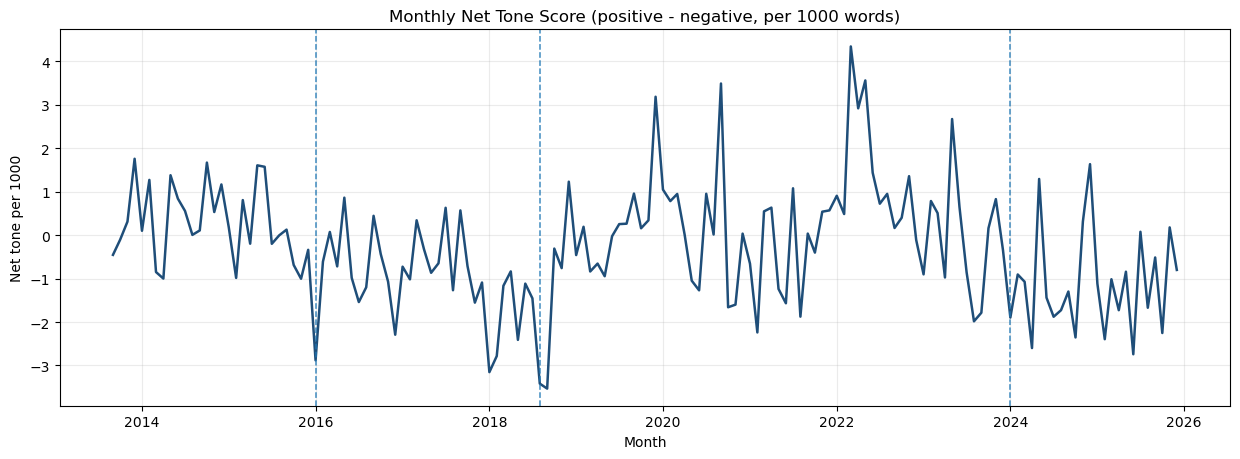

Saved: c:\PythonProjects\AfD-project\figures\10_notebook_figures\monthly_net_tone_score_over_time.png


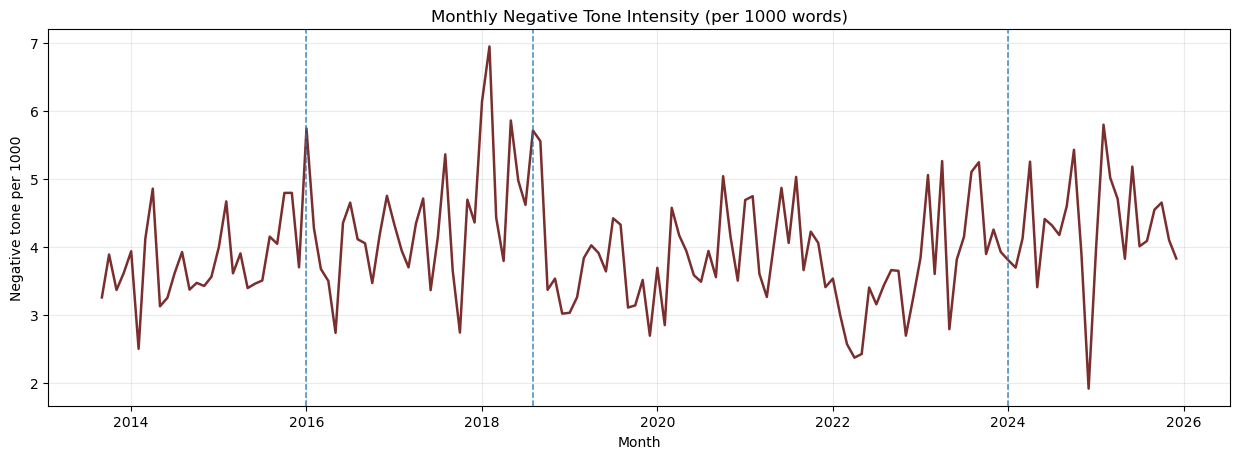

Saved: c:\PythonProjects\AfD-project\figures\10_notebook_figures\monthly_negative_tone_intensity_over_time.png


In [8]:
def add_shock_lines(ax):
    for label, dt in SHOCKS.items():
        ax.axvline(dt, linestyle='--', linewidth=1.1, alpha=0.85)

fig, ax = plt.subplots(figsize=(12.5, 4.7))
ax.plot(panel_tone['month_dt'], panel_tone['tone_net_score_per_1000_mean'], color='#1f4e79', linewidth=1.8)
add_shock_lines(ax)
ax.set_title('Monthly Net Tone Score (positive - negative, per 1000 words)')
ax.set_xlabel('Month')
ax.set_ylabel('Net tone per 1000')
ax.grid(alpha=0.25)
fig.tight_layout()
out = FIGURES_DIR / 'monthly_net_tone_score_over_time.png'
fig.savefig(out, dpi=160)
plt.show()
print('Saved:', out)

fig, ax = plt.subplots(figsize=(12.5, 4.7))
ax.plot(panel_tone['month_dt'], panel_tone['tone_negative_terms_per_1000_mean'], color='#7a2e2e', linewidth=1.8)
add_shock_lines(ax)
ax.set_title('Monthly Negative Tone Intensity (per 1000 words)')
ax.set_xlabel('Month')
ax.set_ylabel('Negative tone per 1000')
ax.grid(alpha=0.25)
fig.tight_layout()
out = FIGURES_DIR / 'monthly_negative_tone_intensity_over_time.png'
fig.savefig(out, dpi=160)
plt.show()
print('Saved:', out)


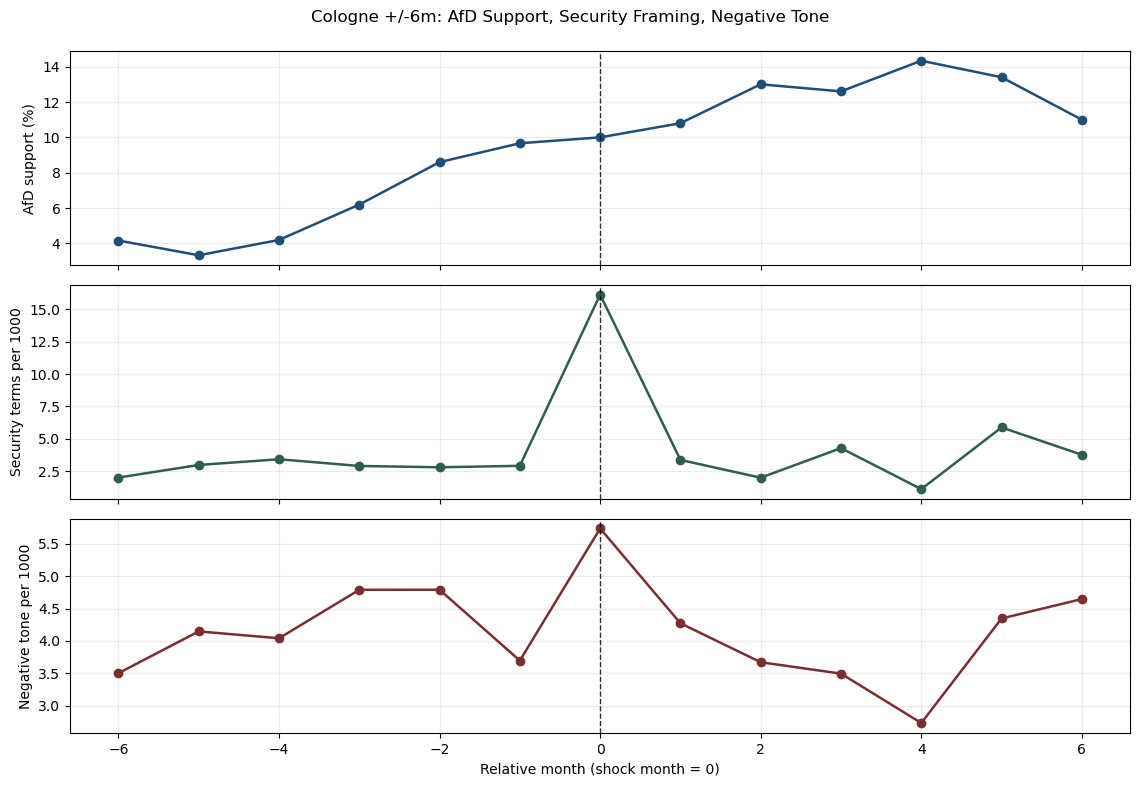

Saved: c:\PythonProjects\AfD-project\figures\10_notebook_figures\cologne_local_tone_security.png


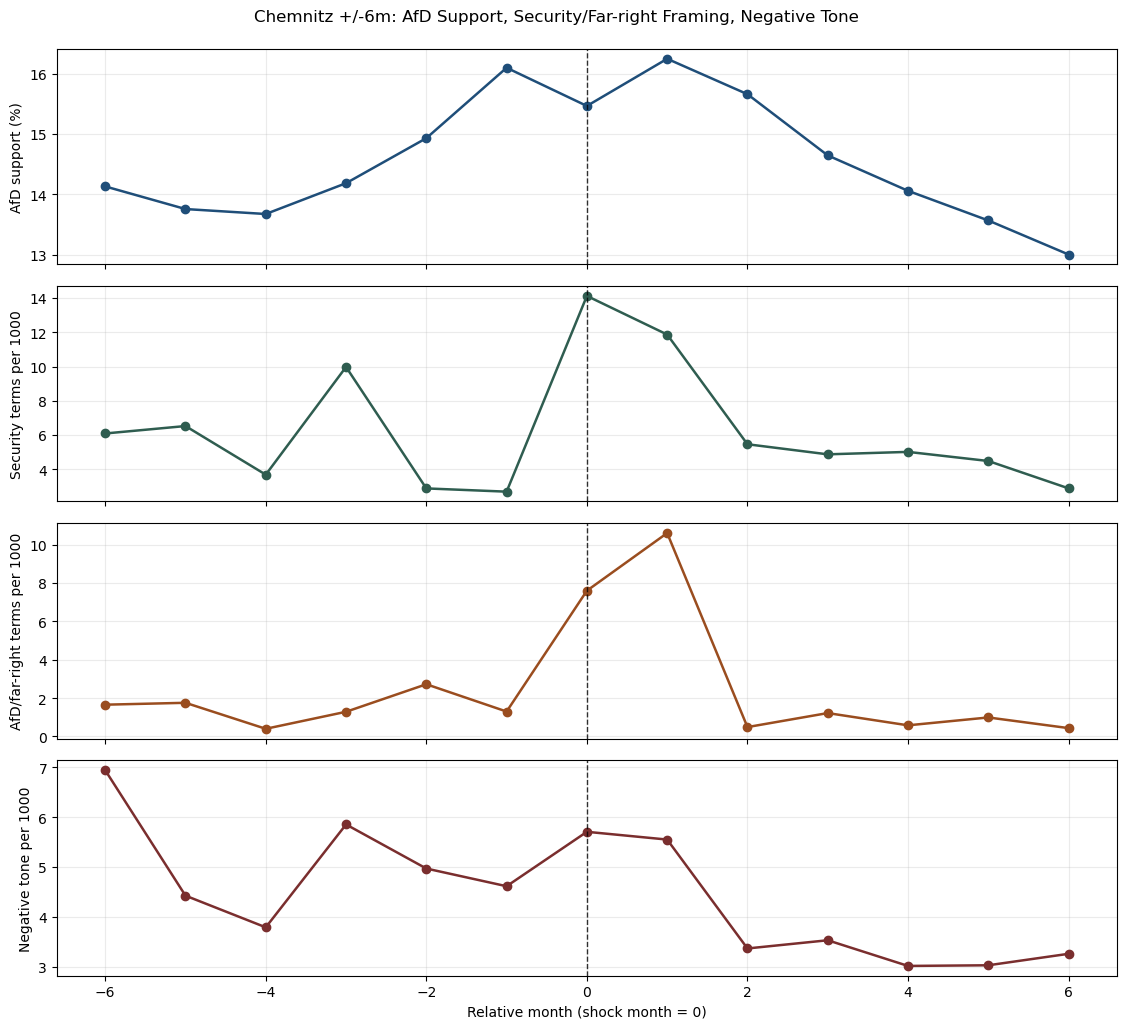

Saved: c:\PythonProjects\AfD-project\figures\10_notebook_figures\chemnitz_local_tone_security_far_right.png


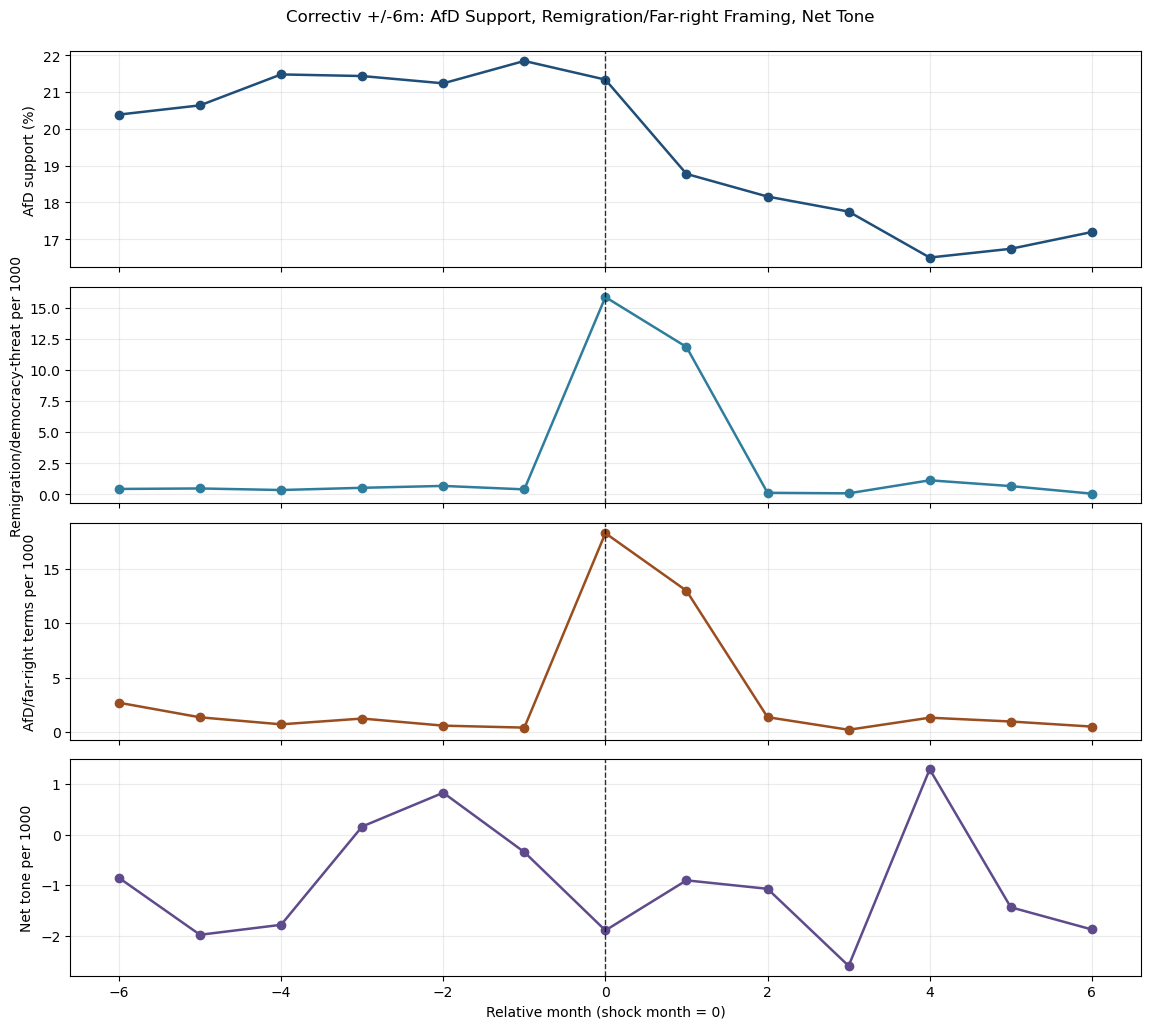

Saved: c:\PythonProjects\AfD-project\figures\10_notebook_figures\correctiv_local_tone_remigration_far_right.png


In [9]:
def local_window(df: pd.DataFrame, shock_month: pd.Timestamp, win: int = 6) -> pd.DataFrame:
    w = df[(df['month_dt'] >= shock_month - pd.DateOffset(months=win)) & (df['month_dt'] <= shock_month + pd.DateOffset(months=win))].copy()
    w['rel_month'] = ((w['month_dt'].dt.year - shock_month.year) * 12 + (w['month_dt'].dt.month - shock_month.month)).astype(int)
    return w.sort_values('rel_month').reset_index(drop=True)


def plot_local_stacked(w: pd.DataFrame, specs: list[tuple[str, str, str]], title: str, out_path: Path):
    n = len(specs)
    fig, axes = plt.subplots(n, 1, figsize=(11.5, 2.45 * n + 0.5), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, (col, ylab, color) in zip(axes, specs):
        ax.plot(w['rel_month'], pd.to_numeric(w[col], errors='coerce'), marker='o', linewidth=1.8, color=color)
        ax.axvline(0, linestyle='--', linewidth=1.0, color='black', alpha=0.8)
        ax.set_ylabel(ylab)
        ax.grid(alpha=0.25)

    axes[-1].set_xlabel('Relative month (shock month = 0)')
    fig.suptitle(title, y=0.995)
    fig.tight_layout()
    fig.savefig(out_path, dpi=160)
    plt.show()
    print('Saved:', out_path)

w_cologne = local_window(panel_tone, SHOCKS['Cologne'], win=6)
plot_local_stacked(
    w_cologne,
    [
        ('afd_poll_support_mean', 'AfD support (%)', '#1f4e79'),
        ('security_terms_per_1000_mean', 'Security terms per 1000', '#2f5d50'),
        ('tone_negative_terms_per_1000_mean', 'Negative tone per 1000', '#7a2e2e'),
    ],
    'Cologne +/-6m: AfD Support, Security Framing, Negative Tone',
    FIGURES_DIR / 'cologne_local_tone_security.png'
)

w_chemnitz = local_window(panel_tone, SHOCKS['Chemnitz'], win=6)
plot_local_stacked(
    w_chemnitz,
    [
        ('afd_poll_support_mean', 'AfD support (%)', '#1f4e79'),
        ('security_terms_per_1000_mean', 'Security terms per 1000', '#2f5d50'),
        ('afd_far_right_terms_per_1000_mean', 'AfD/far-right terms per 1000', '#9a4d1f'),
        ('tone_negative_terms_per_1000_mean', 'Negative tone per 1000', '#7a2e2e'),
    ],
    'Chemnitz +/-6m: AfD Support, Security/Far-right Framing, Negative Tone',
    FIGURES_DIR / 'chemnitz_local_tone_security_far_right.png'
)

w_correctiv = local_window(panel_tone, SHOCKS['Correctiv'], win=6)
plot_local_stacked(
    w_correctiv,
    [
        ('afd_poll_support_mean', 'AfD support (%)', '#1f4e79'),
        ('remigration_democracy_terms_per_1000_mean', 'Remigration/democracy-threat per 1000', '#2f7d9d'),
        ('afd_far_right_terms_per_1000_mean', 'AfD/far-right terms per 1000', '#9a4d1f'),
        ('tone_net_score_per_1000_mean', 'Net tone per 1000', '#5f4b8b'),
    ],
    'Correctiv +/-6m: AfD Support, Remigration/Far-right Framing, Net Tone',
    FIGURES_DIR / 'correctiv_local_tone_remigration_far_right.png'
)


In [10]:
def get_change(df: pd.DataFrame, shock: str, var: str, win: int = 6) -> float:
    sub = df[(df['shock_label'] == shock) & (df['variable'] == var) & (df['window_months'] == win)]
    if len(sub) != 1:
        return np.nan
    return float(sub['change_post_minus_pre'].iloc[0])

cologne_afd = get_change(supp_shock, 'Cologne', 'afd_poll_support_mean', 6)
cologne_sec = get_change(supp_shock, 'Cologne', 'security_terms_per_1000_mean', 6)
cologne_tone_neg = get_change(supp_shock, 'Cologne', 'tone_negative_terms_per_1000_mean', 6)

chemnitz_afd = get_change(supp_shock, 'Chemnitz', 'afd_poll_support_mean', 6)
chemnitz_sec = get_change(supp_shock, 'Chemnitz', 'security_terms_per_1000_mean', 6)
chemnitz_far = get_change(supp_shock, 'Chemnitz', 'afd_far_right_terms_per_1000_mean', 6)
chemnitz_tone_neg = get_change(supp_shock, 'Chemnitz', 'tone_negative_terms_per_1000_mean', 6)

correctiv_afd = get_change(supp_shock, 'Correctiv', 'afd_poll_support_mean', 6)
correctiv_remig = get_change(supp_shock, 'Correctiv', 'remigration_democracy_terms_per_1000_mean', 6)
correctiv_far = get_change(supp_shock, 'Correctiv', 'afd_far_right_terms_per_1000_mean', 6)
correctiv_tone_neg = get_change(supp_shock, 'Correctiv', 'tone_negative_terms_per_1000_mean', 6)
correctiv_tone_net = get_change(supp_shock, 'Correctiv', 'tone_net_score_per_1000_mean', 6)

if cologne_afd > 0 and cologne_sec > 0 and cologne_tone_neg > 0:
    cologne_msg = 'Tone reinforces Cologne mechanism (polling, security framing, and negative tone move upward in +/-6m).'
elif cologne_afd > 0 and cologne_sec > 0:
    cologne_msg = 'Tone qualifies Cologne mechanism (polling/security rise, but negative tone does not rise in parallel).'
else:
    cologne_msg = 'Tone is not fully aligned with the Cologne mechanism pattern in this descriptive window.'

if abs(chemnitz_afd) <= 1.0 and chemnitz_sec > 0 and chemnitz_far > 0 and chemnitz_tone_neg > 0:
    chemnitz_msg = 'Tone reinforces Chemnitz framing interpretation (strong framing and negative-tone rise with limited net polling shift).'
elif chemnitz_sec > 0 and chemnitz_far > 0:
    chemnitz_msg = 'Tone qualifies Chemnitz interpretation (framing rises, but tone/polling pattern is mixed).'
else:
    chemnitz_msg = 'Tone does not clearly support the Chemnitz framing pattern in this window.'

if correctiv_afd < 0 and correctiv_remig > 0 and correctiv_far > 0 and (correctiv_tone_neg > 0 or correctiv_tone_net < 0):
    correctiv_msg = 'Tone reinforces Correctiv interpretation (polling declines while mechanism-specific framing and adverse tone signals intensify).'
elif correctiv_afd < 0 and (correctiv_remig > 0 or correctiv_far > 0):
    correctiv_msg = 'Tone qualifies Correctiv interpretation (polling/framing align, tone signal only partially aligned).'
else:
    correctiv_msg = 'Tone does not clearly support the Correctiv mechanism pattern in this descriptive window.'

contradictions = []
if cologne_afd > 0 and cologne_tone_neg < 0:
    contradictions.append('Cologne: positive polling shift with declining negative tone.')
if abs(chemnitz_afd) <= 1.0 and chemnitz_tone_neg < 0:
    contradictions.append('Chemnitz: limited polling shift and declining negative tone despite framing spike.')
if correctiv_afd < 0 and correctiv_tone_neg < 0 and correctiv_tone_net > 0:
    contradictions.append('Correctiv: polling decline but tone becomes less negative.')

print('Interpretation summary (supplementary tone):')
print('1) Cologne:', cologne_msg)
print('2) Chemnitz:', chemnitz_msg)
print('3) Correctiv:', correctiv_msg)
if contradictions:
    print('4) Potential contradictions:')
    for c in contradictions:
        print('-', c)
else:
    print('4) Potential contradictions: none strong at this aggregation level.')

note_lines = [
    '# Supplementary Media Tone Results Note',
    '',
    'Last updated: 2026-05-12',
    '',
    '## Positioning',
    '- Tone is a supplementary diagnostic layer.',
    '- Main analysis remains media salience + framing/content indicators.',
    '- Findings below are descriptive and mechanism-oriented, not fully identified causal effects.',
    '',
    '## Summary by Shock (descriptive, +/-6m windows)',
    f'- Cologne: {cologne_msg}',
    f'- Chemnitz: {chemnitz_msg}',
    f'- Correctiv: {correctiv_msg}',
    '',
    '## Caveat',
    '- The tone proxy is lexicon-based and transparent, but it is not a target-specific sentiment classifier.',
]
SUPP_NOTE_MD.write_text('\n'.join(note_lines), encoding='utf-8')
print('Saved supplementary note:', SUPP_NOTE_MD)



Interpretation summary (supplementary tone):
1) Cologne: Tone qualifies Cologne mechanism (polling/security rise, but negative tone does not rise in parallel).
2) Chemnitz: Tone qualifies Chemnitz interpretation (framing rises, but tone/polling pattern is mixed).
3) Correctiv: Tone reinforces Correctiv interpretation (polling declines while mechanism-specific framing and adverse tone signals intensify).
4) Potential contradictions:
- Cologne: positive polling shift with declining negative tone.
- Chemnitz: limited polling shift and declining negative tone despite framing spike.
Saved supplementary note: c:\PythonProjects\AfD-project\docs\supplementary_media_tone_results_note.md


In [11]:
final_outputs = [
    ARTICLE_TONE_CSV,
    ARTICLE_TONE_PARQUET,
    MONTHLY_TONE_CSV,
    MONTHLY_TONE_PARQUET,
    FULL_PANEL_TONE_CSV,
    FULL_PANEL_TONE_PARQUET,
    TONE_SHOCK_SUMMARY_CSV,
    SUPP_NOTE_MD,
    FIGURES_DIR / 'monthly_net_tone_score_over_time.png',
    FIGURES_DIR / 'monthly_negative_tone_intensity_over_time.png',
    FIGURES_DIR / 'cologne_local_tone_security.png',
    FIGURES_DIR / 'chemnitz_local_tone_security_far_right.png',
    FIGURES_DIR / 'correctiv_local_tone_remigration_far_right.png',
]

print('Final checkpoint:')
print('panel with tone rows:', len(panel_tone))
print('panel with tone coverage:', panel_tone['year_month'].min(), 'to', panel_tone['year_month'].max())
print('duplicate panel months:', int(panel_tone['year_month'].duplicated().sum()))
for c in KEY_EXISTING_COLS:
    print(f'missing existing {c}:', int(panel_tone[c].isna().sum()))
for c in [
    'tone_positive_terms_per_1000_mean',
    'tone_negative_terms_per_1000_mean',
    'tone_net_score_per_1000_mean',
    'tone_negative_share_mean',
    'share_articles_negative_tone',
]:
    print(f'missing tone {c}:', int(panel_tone[c].isna().sum()))

print('Generated paths:')
for p in final_outputs:
    print('-', p, 'exists=', p.exists())


Final checkpoint:
panel with tone rows: 148
panel with tone coverage: 2013-09 to 2025-12
duplicate panel months: 0
missing existing afd_poll_support_mean: 0
missing existing nexis_total_results: 0
missing existing migration_terms_per_1000_mean: 0
missing existing security_terms_per_1000_mean: 0
missing existing afd_far_right_terms_per_1000_mean: 0
missing existing remigration_democracy_terms_per_1000_mean: 0
missing tone tone_positive_terms_per_1000_mean: 0
missing tone tone_negative_terms_per_1000_mean: 0
missing tone tone_net_score_per_1000_mean: 0
missing tone tone_negative_share_mean: 0
missing tone share_articles_negative_tone: 0
Generated paths:
- c:\PythonProjects\AfD-project\data\indicators\article_media_tone_indicators.csv exists= True
- c:\PythonProjects\AfD-project\data\indicators\article_media_tone_indicators.parquet exists= True
- c:\PythonProjects\AfD-project\data\indicators\monthly_media_tone_indicators.csv exists= True
- c:\PythonProjects\AfD-project\data\indicators\mon